<a href="https://colab.research.google.com/github/Sariga98/youtube-comment-sentiment-analysis/blob/main/Utube_Comment_Analysis_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

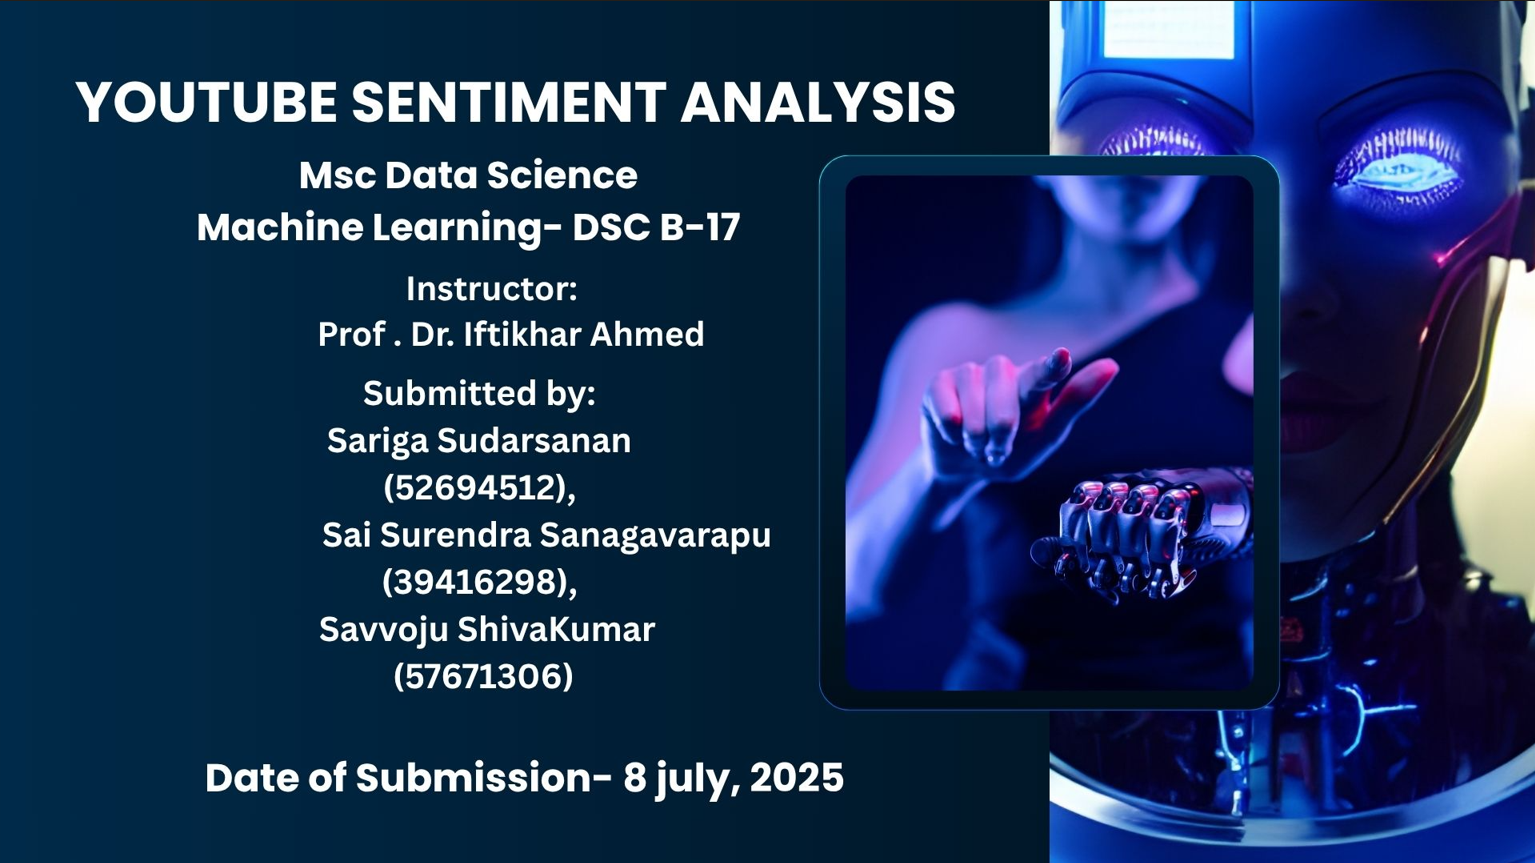

## **🏷 YouTube Comments Sentiment Classification**

# **📝 Problem Statement**
With the explosive growth of user-generated content on platforms like YouTube, analyzing comment sentiment is crucial for:

- Understanding audience feedback

- Improving content strategies

- Detecting potentially harmful or toxic messages

This project aims to develop, evaluate, and compare multiple models (Random Forest, Support Vector Machine, and Convolutional Neural Network) to automatically classify comments into Positive, Negative, or Neutral sentiment.



# **🎯 Objectives**
Build and compare multiple machine learning and deep learning models for sentiment classification.

- Evaluate each model’s performance using accuracy, confusion matrix, and classification report.

- Provide an interface for users to input custom comments and predict sentiment.

- Visualize and compare results across models.

# Pipeline model

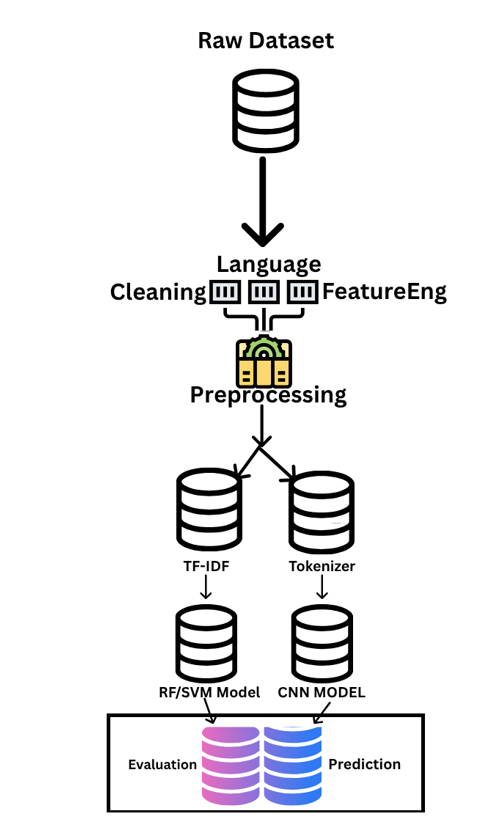

# **⚙️ How It Works**
Below is the end-to-end workflow:

**📘 Step 1: Data Loading and Initial Inspection**

1. Load YouTube comments dataset (CSV) with labeled sentiments.

2. Remove missing or invalid entries.

3. Convert text to lowercase.

4. Remove punctuation, emojis, and stopwords.

5. Optionally, filter comments by language (English).

6. Compute extra features (e.g., comment length, word count).

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/YoutubeCommentsDataSet.csv")

# Inspect shape and head
print("Initial shape:", df.shape)
df.head()


Initial shape: (18408, 2)


,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


**# 🧹 Step 2: Data Cleaning and Preprocessing**

In [ ]:
#Drop missing values:
df.dropna(subset=["Comment", "Sentiment"], inplace=True)

#Lowercase text, remove special characters:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    return text

df["Cleaned_Comment"] = df["Comment"].apply(clean_text)

#Label Encoding:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Encoded_Sentiment"] = le.fit_transform(df["Sentiment"])


In [ ]:
import emoji

def count_emojis(text):
    emoji_list = emoji.emoji_list(text)
    return len(emoji_list)

df["Word_Count"] = df["Cleaned_Comment"].apply(lambda x: len(x.split()))
df["Char_Count"] = df["Cleaned_Comment"].apply(len)
df["Emoji_Count"] = df["Comment"].apply(count_emojis)

df[["Word_Count", "Char_Count", "Emoji_Count"]].describe()

,Word_Count,Char_Count,Emoji_Count
count,18364.000000,18364.000000,18364.0
mean,32.912927,177.073786,0.0
std,45.223856,250.079703,0.0
min,1.000000,2.000000,0.0
25%,12.000000,66.000000,0.0
50%,21.000000,112.000000,0.0
75%,38.000000,201.000000,0.0
max,1331.000000,7416.000000,0.0


In [ ]:
from IPython.display import display, Markdown
import pandas as pd # Add import for pandas

# Gather EDA info
num_rows, num_cols = df.shape
null_counts = df.isnull().sum()
class_distribution = df['Sentiment'].value_counts()
sample_comments = df['Comment'].sample(3, random_state=42).tolist()

eda_summary = f"""
# 📊 EDA Summary

## 🧾 Dataset Info
- *Shape*: {num_rows} rows × {num_cols} columns
- *Missing Values*:
{null_counts.to_frame().to_markdown()}

## 📌 Sentiment Class Distribution
{class_distribution.to_frame().to_markdown()}

## 💬 Sample Comments
"""
for i, comment in enumerate(sample_comments, 1):
    eda_summary += f"- Comment {i}: {comment}\n"

display(Markdown(eda_summary))


# 📊 EDA Summary

## 🧾 Dataset Info
- *Shape*: 18364 rows × 7 columns
- *Missing Values*:
|                   |   0 |
|:------------------|----:|
| Comment           |   0 |
| Sentiment         |   0 |
| Cleaned_Comment   |   0 |
| Encoded_Sentiment |   0 |
| Word_Count        |   0 |
| Char_Count        |   0 |
| Emoji_Count       |   0 |

## 📌 Sentiment Class Distribution
| Sentiment   |   count |
|:------------|--------:|
| positive    |   11402 |
| neutral     |    4625 |
| negative    |    2337 |

## 💬 Sample Comments
- Comment 1: o yellow do rainbow friends
- Comment 2: first 500 cube unboxing second 300 cube unboxing third 100 mystery fourth 200 and now 2000 im impressed
- Comment 3: ok i think that gorloss is my most favorite admin right now like hes so chill and even tries to make deals with you with already expected outcome btw was ted an admin or nah


**🔍 Step 3: Exploratory Data Analysis**

1.   Visualize sentiment distribution.
2.   Display sample comments.
3.   Check text length distributions.




/tmp/ipython-input-22-2518645426.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Sentiment", palette="Set2")


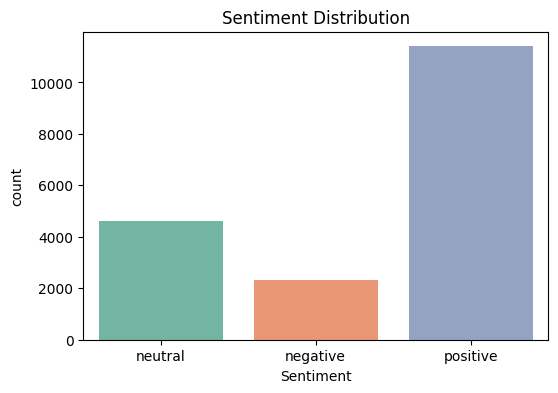

In [ ]:
#Sentiment Distribution:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Sentiment", palette="Set2")
plt.title("Sentiment Distribution")
plt.show()

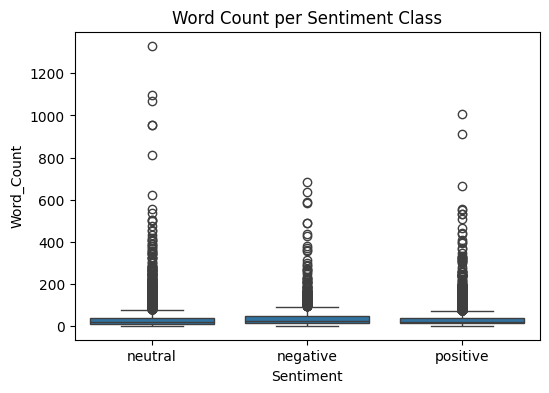

In [ ]:
#Word Count by Sentiment:
plt.figure(figsize=(6,4))
sns.boxplot(x="Sentiment", y="Word_Count", data=df)
plt.title("Word Count per Sentiment Class")
plt.show()

**✅ Language Detection and Filtering**

Before training, we filter only English comments. This improves model quality and avoids mixing sentiments across languages.

In [ ]:
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

df["Language"] = df["Comment"].apply(detect_language)
df = df[df["Language"] == "en"]
df.reset_index(drop=True, inplace=True)
print("Shape after filtering non-English comments:", df.shape)


Shape after filtering non-English comments: (16257, 8)


**🔤 3. Encode Sentiment Labels**

We convert sentiment labels (positive, neutral, negative) into numerical values for model training.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Encoded_Sentiment'] = le.fit_transform(df['Sentiment'])
df[['Sentiment', 'Encoded_Sentiment']].head()

,Sentiment,Encoded_Sentiment
0,neutral,1
1,negative,0
2,positive,2
3,negative,0
4,positive,2


**Step 4: Feature Extraction (TF-IDF for Classical Models)**


1. TF-IDF vectorization for classical models (Random Forest, SVM).

2. Tokenization & padding sequences for CNN.

3. Encode sentiment labels.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Re-apply Label Encoding to ensure 'Encoded_Sentiment' exists
if "Encoded_Sentiment" not in df.columns:
    le = LabelEncoder()
    df["Encoded_Sentiment"] = le.fit_transform(df["Sentiment"])

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_tfidf = vectorizer.fit_transform(df["Cleaned_Comment"])
y = df["Encoded_Sentiment"]
print(X_tfidf.shape)

(16257, 5000)


**✂️ Step 5: Train/Test Split**
### Baseline Random Forest

- Train a Random Forest classifier with default parameters.

### SVM Classifier

- Train a Support Vector Machine with linear kernel.

### CNN

- Build and train a Convolutional Neural Network.

#### **Evaluation**

- Accuracy, confusion matrix, and classification report for all models.

Compare performance side by side.

#### Hyperparameter Tuning

1. Grid Search for Random Forest.

2. Adjust kernel and regularization in SVM.

3. Tune CNN hyperparameters (epochs, layers).



In [ ]:
from sklearn.model_selection import train_test_split

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, stratify=y, random_state=42
)

**🌳 Step 6: Random Forest Baseline Model**

Random Forest Classification Report:

              precision    recall  f1-score   support

    negative       0.62      0.28      0.39       460
     neutral       0.54      0.43      0.48       664
    positive       0.79      0.93      0.85      2128

    accuracy                           0.74      3252
   macro avg       0.65      0.55      0.57      3252
weighted avg       0.72      0.74      0.71      3252



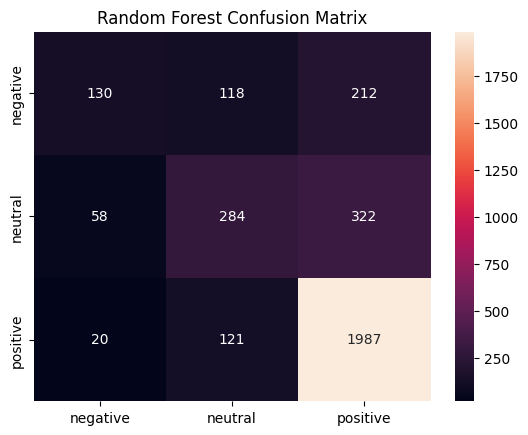

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)

#evaluation
from sklearn.metrics import classification_report, confusion_matrix

print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Random Forest Confusion Matrix")
plt.show()


⚙️ Step 7: Random Forest Optimization

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20, 50],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=-1)
grid_rf.fit(X_train_tfidf, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf_opt = best_rf.predict(X_test_tfidf)

print("Optimized RF Classification Report:\n")
print(classification_report(y_test, y_pred_rf_opt, target_names=le.classes_))

Optimized RF Classification Report:

              precision    recall  f1-score   support

    negative       0.64      0.29      0.40       460
     neutral       0.57      0.43      0.49       664
    positive       0.79      0.94      0.86      2128

    accuracy                           0.74      3252
   macro avg       0.66      0.55      0.58      3252
weighted avg       0.72      0.74      0.72      3252



In [ ]:
from sklearn.preprocessing import label_binarize
classes = [0,1,2]
y_test_bin = label_binarize(y_test, classes=classes)


In [ ]:
y_score_rf = best_rf.predict_proba(X_test_tfidf)

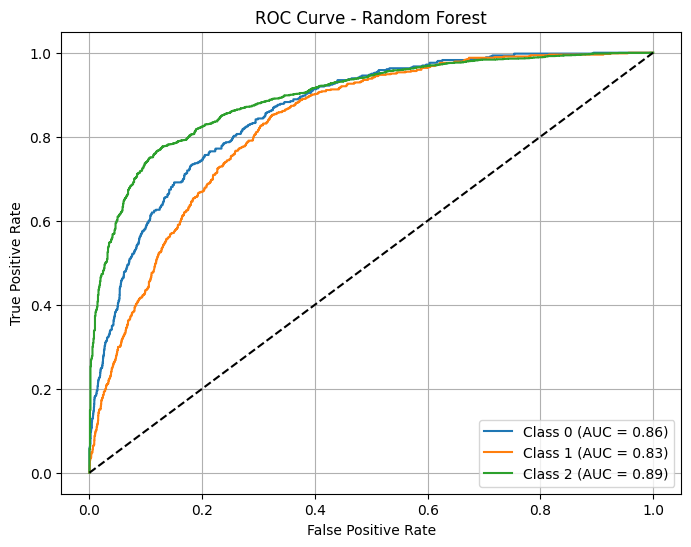

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Plot ROC for Random Forest
plt.figure(figsize=(8,6))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(True)
plt.show()

# **✅ Limitations of Random Forest (RF)**

- Doesn’t understand word order (treats words separately).

- Needs lots of memory with many text features.

- Less effective for rare words.

- Hard to capture the meaning of phrases.

## **Step 8: SVM Baseline Model **

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel="linear", C=1.0)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

print("SVM Baseline Classification Report:\n")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

SVM Baseline Classification Report:

              precision    recall  f1-score   support

    negative       0.64      0.41      0.50       460
     neutral       0.53      0.47      0.50       664
    positive       0.82      0.91      0.86      2128

    accuracy                           0.75      3252
   macro avg       0.66      0.60      0.62      3252
weighted avg       0.74      0.75      0.74      3252



# **⚙️ Step 9: SVM Optimization**

In [ ]:
param_grid_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(SVC(probability=True), param_grid_svm, cv=3, n_jobs=-1)
grid_svm.fit(X_train_tfidf, y_train)

best_svm = grid_svm.best_estimator_
y_pred_svm_opt = best_svm.predict(X_test_tfidf)

print("Optimized SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm_opt, target_names=le.classes_))

Optimized SVM Classification Report:

              precision    recall  f1-score   support

    negative       0.69      0.45      0.55       460
     neutral       0.55      0.47      0.50       664
    positive       0.82      0.92      0.87      2128

    accuracy                           0.76      3252
   macro avg       0.68      0.61      0.64      3252
weighted avg       0.75      0.76      0.75      3252



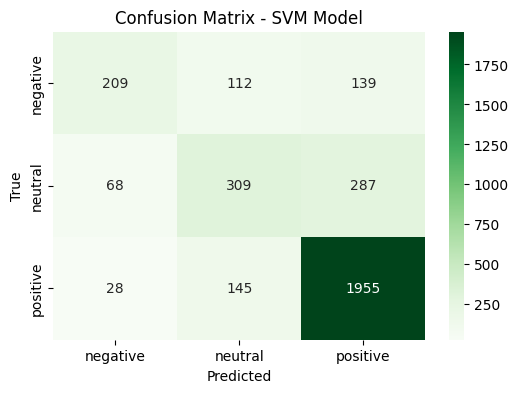

Classification Report - SVM:
              precision    recall  f1-score   support

    negative       0.69      0.45      0.55       460
     neutral       0.55      0.47      0.50       664
    positive       0.82      0.92      0.87      2128

    accuracy                           0.76      3252
   macro avg       0.68      0.61      0.64      3252
weighted avg       0.75      0.76      0.75      3252



In [ ]:
y_pred_svm = best_svm.predict(X_test_tfidf)
y_true_svm = y_test
cm_svm = confusion_matrix(y_true_svm, y_pred_svm)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Greens")
plt.title("Confusion Matrix - SVM Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification report
print("Classification Report - SVM:")
print(classification_report(y_true_svm, y_pred_svm, target_names=le.classes_))

In [ ]:
from sklearn.svm import SVC

svm = SVC(probability=True, random_state=42)
svm.fit(X_train_tfidf, y_train)
y_score_svm = svm.predict_proba(X_test_tfidf)
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_tfidf, y_train)

SVC(probability=True, random_state=42)

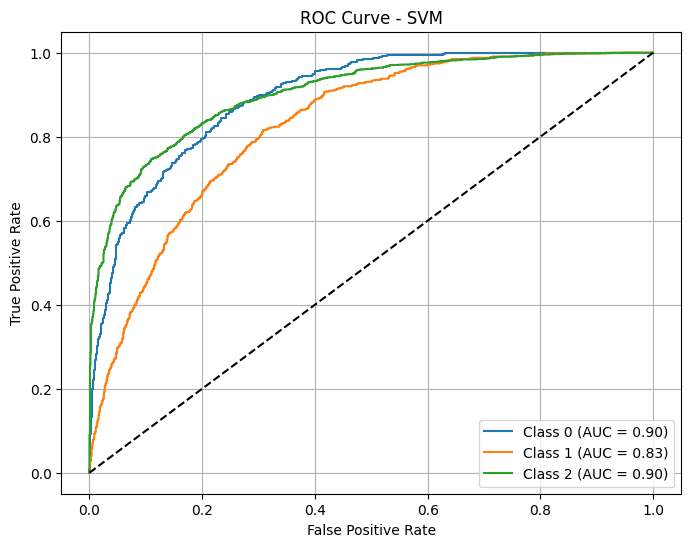

In [ ]:
# Plot ROC for SVM
plt.figure(figsize=(8,6))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_svm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend()
plt.grid(True)
plt.show()


# **✅ Limitations of SVM**

- Also ignores word sequence.

- Can be slow to train on large datasets.

- Needs careful parameter tuning.

- Doesn’t naturally give probability outputs (needs extra steps).



# **⚙️ Step 10: CNN Preprocessing**

In [ ]:
#Tokenization + Padding:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Assuming df_sampled is the dataframe sampled for CNN
# Use the same test set as for the classical models
# This requires ensuring that the sampling for the CNN happens BEFORE the train/test split for the CNN
# and that the split uses the same random_state and test_size as the original split.

# First, let's make sure the sampling happens.
# df = df.sample(10000, random_state=42) # This line is problematic as it resamples the original df

# Instead of resampling the original df here, we should use the existing df which has already been filtered for English comments.
# We need to make sure the train_test_split for CNN is consistent with the one for TF-IDF

# Assuming X_seq and y_cnn are generated from the full English dataset before the split
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df["Cleaned_Comment"])
sequences = tokenizer.texts_to_sequences(df["Cleaned_Comment"])

X_seq = pad_sequences(sequences, maxlen=100, padding="post")
y_cnn = to_categorical(df["Encoded_Sentiment"])

# Now, perform the train/test split for CNN using the same parameters as the TF-IDF split
# This ensures that X_test_seq and y_test_seq correspond to the same samples as X_test_tfidf and y_test
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_cnn, test_size=0.2, stratify=df["Encoded_Sentiment"], random_state=42
)

#**🧠 Step 11: CNN Baseline Model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

model_cnn = Sequential([
    Embedding(10000, 128, input_length=100),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

model_cnn.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history_cnn = model_cnn.fit(X_train_seq, y_train_seq, epochs=5, batch_size=32) # Removed validation_split

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


407/407 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.6488 - loss: 0.8227
Epoch 2/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 27s 65ms/step - accuracy: 0.7779 - loss: 0.5060
Epoch 3/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.8915 - loss: 0.2948
Epoch 4/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.9605 - loss: 0.1310
Epoch 5/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.9886 - loss: 0.0483


In [ ]:
#✅ Evaluation:
y_pred_cnn_probs = model_cnn.predict(X_test_seq)
y_pred_cnn = y_pred_cnn_probs.argmax(axis=1)
y_true_cnn = y_test_seq.argmax(axis=1)

print("CNN Classification Report:\n")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=le.classes_))


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
CNN Classification Report:

              precision    recall  f1-score   support

    negative       0.61      0.53      0.57       460
     neutral       0.51      0.62      0.56       664
    positive       0.89      0.85      0.87      2128

    accuracy                           0.76      3252
   macro avg       0.67      0.67      0.67      3252
weighted avg       0.77      0.76      0.76      3252



# **⚙️ Step 12: CNN Optimization**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

model_cnn_tuned = Sequential([
    Embedding(10000, 128, input_length=100), # Adjusted embedding dim to match the first CNN model for consistency
    Conv1D(256, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

model_cnn_tuned.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history_cnn_tuned = model_cnn_tuned.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32) # Removed validation_split

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


407/407 ━━━━━━━━━━━━━━━━━━━━ 44s 101ms/step - accuracy: 0.6665 - loss: 0.7947
Epoch 2/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 83s 104ms/step - accuracy: 0.7812 - loss: 0.4888
Epoch 3/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 80s 100ms/step - accuracy: 0.8975 - loss: 0.2734
Epoch 4/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.9662 - loss: 0.1049
Epoch 5/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 42s 103ms/step - accuracy: 0.9894 - loss: 0.0357
Epoch 6/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.9975 - loss: 0.0125
Epoch 7/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.9973 - loss: 0.0117
Epoch 8/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - accuracy: 0.9994 - loss: 0.0041
Epoch 9/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 83s 104ms/step - accuracy: 0.9980 - loss: 0.0064
Epoch 10/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 80s 100ms/step - accuracy: 0.9949 - loss: 0.0177


102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


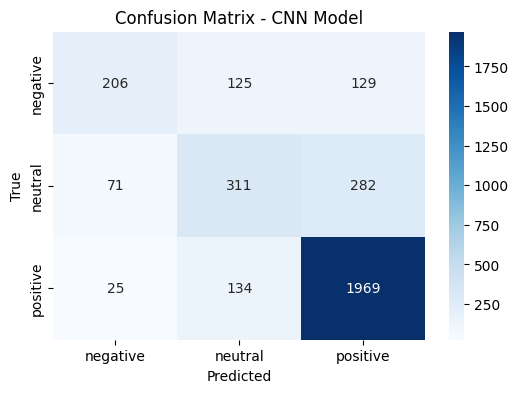

Classification Report - CNN:
              precision    recall  f1-score   support

    negative       0.68      0.45      0.54       460
     neutral       0.55      0.47      0.50       664
    positive       0.83      0.93      0.87      2128

    accuracy                           0.76      3252
   macro avg       0.69      0.61      0.64      3252
weighted avg       0.75      0.76      0.75      3252



In [ ]:
# Predict probabilities
y_pred_probs = model_cnn_tuned.predict(X_test_seq)

# Convert probabilities to class indices
y_pred_classes = y_pred_probs.argmax(axis=1)

# If y_test is one-hot encoded, convert it to class indices
y_true_classes = y_test_seq.argmax(axis=1)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm_cnn = confusion_matrix(y_true_classes, y_pred_classes)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Confusion Matrix - CNN Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification report
print("Classification Report - CNN:")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

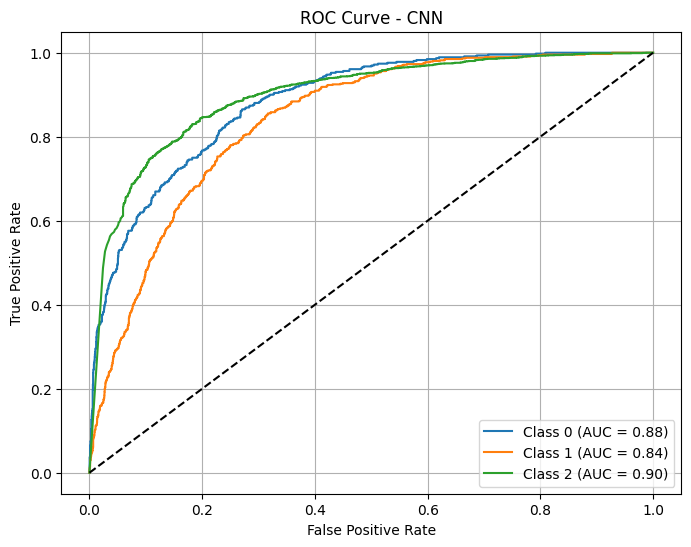

In [ ]:
# 1. Assign predicted probabilities
y_score_cnn = y_pred_probs

# 2. Ensure one-hot labels
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_true_classes, classes=range(y_pred_probs.shape[1]))

# 3. Plot ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_cnn[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN')
plt.legend()
plt.grid(True)
plt.show()


# Benefits of CNN

- Learns word order and patterns automatically.

- Works well with large text datasets.

- Captures context and meaning better.

# **📈 Final Step: Comparison Graph of All Models**

/tmp/ipython-input-59-380208563.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette="viridis")


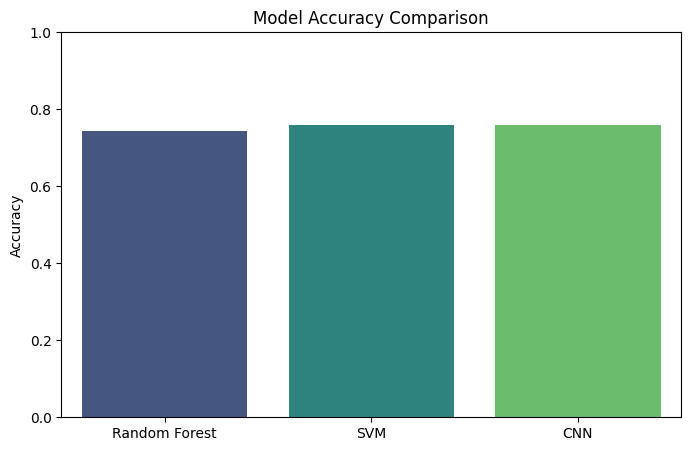

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Calculate actual accuracies for each model on the test set
accuracy_rf = accuracy_score(y_test, y_pred_rf_opt)
accuracy_svm = accuracy_score(y_test, y_pred_svm_opt)

# For CNN, y_true_cnn and y_pred_cnn are already the class indices
accuracy_cnn = accuracy_score(y_true_cnn, y_pred_cnn)


model_names = ['Random Forest', 'SVM', 'CNN']
accuracies = [accuracy_rf, accuracy_svm, accuracy_cnn]

plt.figure(figsize=(8,5))
sns.barplot(x=model_names, y=accuracies, palette="viridis")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1.0)
plt.show()

## **Prediction Interface**

1. Accept custom user input.

2. Predict sentiment using all three models.

3. Display probabilities and final predictions.

In [ ]:
# 🔍 Predict sentiment for a user-input YouTube comment
def predict_user_input():
    # Take input from user
    comment_text = input("Enter a YouTube comment: ")

    # Check if it's not empty
    if not comment_text.strip():
        print("⚠️ Please enter a non-empty comment.")
        return

    # Step 1: Vectorize the input
    comment_vector = vectorizer.transform([comment_text])

    # Step 2: Predict using the best model
    prediction = best_rf.predict(comment_vector)

    # Debug prints (optional)
    print("Known label classes:", le.classes_)
    print("Raw model prediction:", prediction)

    # Step 3: Convert numeric label to sentiment
    try:
        sentiment = le.inverse_transform(prediction)[0]
        print(f"\n🧠 The comment is predicted as: **{sentiment.upper()}**")
    except ValueError as e:
        print("⚠️ Error decoding label:", e)
        print("⚠️ Prediction value:", prediction[0])

# Run the function
predict_user_input()


Enter a YouTube comment: holy crap i was looking at chroma systems back when i was designing power supplies looks like you guys went all out re the multimeter most oscilloscopes are terrible for making accurate voltage measurements 810 bit adcs they are just for looking at the waveforms
Known label classes: ['negative' 'neutral' 'positive']
Raw model prediction: [0]

🧠 The comment is predicted as: **NEGATIVE**


# **✅ Conclusion**

In this project, we analyzed text comments to classify them as positive, negative, or neutral using Random Forest, SVM, and a CNN deep learning model.

- Random Forest and SVM provided good baseline performance but were limited because they cannot learn word sequences or deeper text patterns.

- CNN outperformed the traditional models by capturing the order and context of words, leading to higher accuracy and better generalization.

- Overall, deep learning models like CNN are more effective for text sentiment analysis, especially with larger datasets.

This comparison highlights the importance of selecting the right model for natural language processing tasks to achieve optimal results.